##### *Load in chosen positive controls from Allen Brain hall of fame & all the metadata*

In [40]:
import pandas as pd

AB_pos_ctrls = pd.read_csv(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\SpecimenFileManifest.csv')
AB_metadata = pd.read_csv(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\SpecimenMetadata.csv')

##### *Filter metadata to only contain chosen positive controls*

In [41]:
AB_pos_ctrl_metadata = AB_metadata[AB_metadata['Specimen ID'].isin(AB_pos_ctrls['Specimen ID'])]

In [43]:
AB_pos_ctrl_metadata.columns

Index(['Project ID', 'Specimen ID', 'Donor ID', 'Image Series ID',
       'Donor Genotype', 'Vector ID', 'Addgene ID', 'Vector Full Name',
       'Data Modality', 'Hall of Fame', 'Targeted Cell Population',
       'Targeted Brain Region', 'Coarse Labeled ROI', 'Fine Labeled ROI',
       'Observed Labeled Cell Population',
       'Observed Labeled Cell Population - Brightness',
       'Observed Labeled Cell Population - Density', 'Enhancer ID', 'Cargo',
       'Vector Delivery Method', 'Publication', 'Enhancer Coordinates',
       'GC Delivered (scientific notation)', 'Genome Build (enhancer)'],
      dtype='object')

##### *Create bed file for selected pos_ctrls to intersect with all ATAC peaks from mm10*

In [46]:
# Filter AB_pos_ctrl_metadata to only include enhancers from mm10
AB_pos_ctrl_metadata_f = AB_pos_ctrl_metadata[AB_pos_ctrl_metadata['Genome Build (enhancer)'] == 'mm10']

In [49]:
bed_format = pd.DataFrame({
    'chrom' : AB_pos_ctrl_metadata_f['Enhancer Coordinates'].apply(
        lambda x : x.split(':')[0]
    ),
    'start' : AB_pos_ctrl_metadata_f['Enhancer Coordinates'].apply(
        lambda x : x.split(':')[1].split('-')[0]
    ),
    'end' : AB_pos_ctrl_metadata_f['Enhancer Coordinates'].apply(lambda x : x.split('-')[1]),
    
    'target_ct' : AB_pos_ctrl_metadata_f['Observed Labeled Cell Population'],
    'Enhancer ID' : AB_pos_ctrl_metadata_f['Enhancer ID'],
})

In [50]:
bed_format

,chrom,start,end,target_ct,Enhancer ID
4,chr12,63319591,63319953,L23_Glutamatergic,AiE0680m
9,chr9,57565763,57566393,L6b_Glutamatergic,AiE2586m
10,chr9,56037158,56037698,L6b_Glutamatergic,AiE2356m
13,chr10,75411358,75411847,MSN,AiE0784m
14,chr9,56037158,56037698,L6b_Glutamatergic,AiE2356m
17,chr10,19829364,19829560,MSN_D1,AiE0779m_6xC2
19,chr3,135176738,135176987,Cholinergic,AiE0743m_3xC2
27,chr16,88302522,88302798,L4_Glutamatergic,AiE0050m_3xC2
31,chr1,193298203,193298703,L5a_Glutamatergic,AiE2016m
35,chr3,135176738,135176987,Neuron,AiE0743m_3xC2


In [51]:
bed_format.to_csv(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\pos_ctrls.bed', sep='\t', header=None, index=None)

##### *Create bed file for all mouse ATAC peaks*

In [27]:
cre_ann = pd.read_table(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\my_cre_annot_final.tsv')

In [245]:
cre_ann

,3,encode_overlap,gene_name,distance_to_tss,simple_annot,best_tpr,best_subclass,recall,true_negative_rate,n_subclass_cells,...,max_cpm_rna,max_celltype_rna,entropy-specificity_rna,fold_change_closest_rna,fold_change_average_rna,min_mcg,min_celltype,entropy-specificity_mcg,fold_change_closest_mcg,fold_change_average_mcg
0,chr1:3003659-3004158,False,Xkr4,667589,LINE,0.124793,327_Oligo_NN,0.000366,0.999455,412340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1:3007192-3007691,False,Xkr4,664056,Intergenic,0.083271,327_Oligo_NN,0.000272,0.999366,412340,...,0.027688,AVPV-MEPO-SFO_Tbr1_Glut,7.873253,4.908752,8.016017,0.058369,CBX_Golgi_Gly-Gaba,0.667738,0.098684,3.793447
2,chr1:3012480-3012979,True,Xkr4,658768,Intergenic,0.089336,327_Oligo_NN,0.001778,0.996155,412340,...,0.029357,OB-out_Frmd7_Gaba,6.500078,2.897735,7.621612,0.250000,NTS-MDRNd_Prox1_Zic1_Gly-Gaba,0.215763,0.485332,1.716527
3,chr1:3027149-3027648,False,Xkr4,644099,LINE,0.204584,327_Oligo_NN,0.000584,0.999518,412340,...,0.000000,ABC_NN,NaN,inf,inf,0.125000,DMH_Prdm13_Gaba,0.139224,1.000006,2.523200
4,chr1:3035657-3036156,True,Xkr4,635591,LTR,0.125212,327_Oligo_NN,0.000179,0.999734,412340,...,0.027949,SPVO_Mafa_Meis2_Glut,3.620010,0.910827,5.732208,0.362356,TH_Prkcd_Grin2c_Glut,0.141200,0.150258,1.105922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1053806,chrY:90807497-90807996,False,Erdr1x,22305,intron,0.110110,006_L4/5_IT_CTX_Glut,0.052417,0.976562,123509,...,0.351639,Microglia_NN,0.997772,0.067752,3.729402,0.531828,L4_RSP-ACA_Glut,0.039603,0.079351,0.409457
1053807,chrY:90808588-90809087,False,Erdr1x,23396,intron,0.091431,006_L4/5_IT_CTX_Glut,0.076788,0.957782,123509,...,0.901708,OB_Trdn_Gaba,0.408111,0.912176,3.241368,0.324011,L5_NP_CTX_Glut,0.055532,0.150699,1.137760
1053808,chrY:90809268-90809767,False,Erdr1x,24076,intron,0.244935,006_L4/5_IT_CTX_Glut,0.041600,0.992905,123509,...,0.200425,Microglia_NN,0.514483,0.490509,2.747541,0.281331,L5_NP_CTX_Glut,0.203045,0.159112,1.563199
1053809,chrY:90810672-90811171,False,Erdr1x,25480,intron,0.088205,327_Oligo_NN,0.004639,0.989825,412340,...,0.974124,OB_Trdn_Gaba,0.365037,1.153189,3.207607,0.446078,L4_RSP-ACA_Glut,0.049772,0.117377,0.659185


In [55]:
bed_format_ATAC = pd.DataFrame({
    'chrom' : cre_ann['3'].apply(
        lambda x : x.split(':')[0]
    ),
    'start' : cre_ann['3'].apply(
        lambda x : x.split(':')[1].split('-')[0]
    ),
    'end' : cre_ann['3'].apply(lambda x : x.split('-')[1]),
    
    'best subclass' : cre_ann['best_subclass'],
    'simple annotation' : cre_ann['simple_annot'],
})

In [56]:
bed_format_ATAC

,chrom,start,end,best subclass,simple annotation
0,chr1,3003659,3004158,327_Oligo_NN,LINE
1,chr1,3007192,3007691,327_Oligo_NN,Intergenic
2,chr1,3012480,3012979,327_Oligo_NN,Intergenic
3,chr1,3027149,3027648,327_Oligo_NN,LINE
4,chr1,3035657,3036156,327_Oligo_NN,LTR
...,...,...,...,...,...
1053806,chrY,90807497,90807996,006_L4/5_IT_CTX_Glut,intron
1053807,chrY,90808588,90809087,006_L4/5_IT_CTX_Glut,intron
1053808,chrY,90809268,90809767,006_L4/5_IT_CTX_Glut,intron
1053809,chrY,90810672,90811171,327_Oligo_NN,intron


In [57]:
bed_format_ATAC.to_csv(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\mm10_ATAC_peaks.bed', sep='\t', header=None, index=None)

##### *Intersect the pos_ctrls with the mm10 ATAC peaks using wsl*

In [270]:
def wsl_path(windows_path):
    return windows_path.replace('\\', '/').replace('C:', '/mnt/c')

In [271]:
# define windows and wsl paths to appropriate bed files
bedtools = '/home/zgibbs/miniconda3/envs/utility/bin/bedtools'
pos_ctrls = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\pos_ctrls.bed'
pos_ctrls_wsl = wsl_path(pos_ctrls)
ATAC_peaks = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\mm10_ATAC_peaks.bed'
ATAC_peaks_wsl = wsl_path(ATAC_peaks)
results = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\pos_ctrl_ATAC_intersect.bed'
results_wsl = wsl_path(results)

In [292]:
# define the actual bedtools command to execute
command = f'{bedtools} intersect -a {pos_ctrls_wsl} -b {ATAC_peaks_wsl} -wo > {results_w}'

In [293]:
# define function to write a bash file to execute the defined command
def run_wsl_command(command_str):
    current_directory = os.getcwd()
    tmpfile = str(rf'{current_directory}\wsl_tmp_command.sh')
    with open(tmpfile, 'w+') as wsl_out:
        wsl_out.write('\n'.join(['#!/bin/bash', command_str]))
    return f'wsl -e bash {wsl_path(tmpfile)}'

In [294]:
# define command to run using the bash file generated from the above function
run_command = run_wsl_command(command)
!{run_command}

##### *Examine the positive control enhancers that intersect with ATAC peak regions and their corresponding overlap*

In [298]:
enhancer_peaks = pd.read_table(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\pos_ctrl_ATAC_intersect.bed',
                               names = ['chr (enhancer)','start (enhancer)','end (enhancer)','observed cell type','enhancer ID',
                                          'chr (ATAC)','start (ATAC)','end (ATAC)','ATAC best subclass','peak annotation','overlap'])

enhancer_peaks['enhancer size'] = enhancer_peaks.iloc[:,2] - enhancer_peaks.iloc[:,1]
enhancer_peaks['ATAC peak size'] = enhancer_peaks['end (ATAC)'] - enhancer_peaks['start (ATAC)']

In [299]:
enhancer_peaks

,chr (enhancer),start (enhancer),end (enhancer),observed cell type,enhancer ID,chr (ATAC),start (ATAC),end (ATAC),ATAC best subclass,peak annotation,overlap,enhancer size,ATAC peak size
0,chr12,63319591,63319953,L23_Glutamatergic,AiE0680m,chr12,63319512,63320011,007_L2/3_IT_CTX_Glut,Intergenic,362,362,499
1,chr9,57565763,57566393,L6b_Glutamatergic,AiE2586m,chr9,57565854,57566353,327_Oligo_NN,intron,499,630,499
2,chr9,56037158,56037698,L6b_Glutamatergic,AiE2356m,chr9,56037372,56037871,029_L6b_CTX_Glut,Intergenic,326,540,499
3,chr10,75411358,75411847,MSN,AiE0784m,chr10,75411328,75411827,062_STR_D2_Gaba,intron,469,489,499
4,chr9,56037158,56037698,L6b_Glutamatergic,AiE2356m,chr9,56037372,56037871,029_L6b_CTX_Glut,Intergenic,326,540,499
5,chr10,19829364,19829560,MSN_D1,AiE0779m_6xC2,chr10,19829120,19829619,062_STR_D2_Gaba,Intergenic,196,196,499
6,chr3,135176738,135176987,Cholinergic,AiE0743m_3xC2,chr3,135176596,135177095,071_LSX_Prdm12_Zeb2_Gaba,LINE,249,249,499
7,chr16,88302522,88302798,L4_Glutamatergic,AiE0050m_3xC2,chr16,88302410,88302909,006_L4/5_IT_CTX_Glut,Intergenic,276,276,499
8,chr1,193298203,193298703,L5a_Glutamatergic,AiE2016m,chr1,193298320,193298819,006_L4/5_IT_CTX_Glut,Intergenic,383,500,499
9,chr3,135176738,135176987,Neuron,AiE0743m_3xC2,chr3,135176596,135177095,071_LSX_Prdm12_Zeb2_Gaba,LINE,249,249,499


##### *Manually choose STARR-FISH enhancer regions based on AB enhancer & ATAC peak*

In [ ]:
# make empty list to contain STARR-FISH enhancer data
# final_pos_ctrls = []

In [477]:
x = 26 # index for enhancer

# center of ATAC peak
# start = (enhancer_peaks['start (ATAC)'][x] + ((enhancer_peaks['ATAC peak size'][x] - 190) / 2)).astype(int)
# end = (start + 190).astype(int)
# chr = enhancer_peaks['chr (enhancer)'][x]

# center of enhancer
start = (enhancer_peaks['start (enhancer)'][x] + ((enhancer_peaks['enhancer size'][x] - 190) / 2)).astype(int)
end = (start + 190).astype(int)
chr = enhancer_peaks['chr (enhancer)'][x]

# custom region
# start = (enhancer_peaks['start (enhancer)'][x] + 70).astype(int)
# end = (start + 190).astype(int)
# chr = enhancer_peaks['chr (enhancer)'][x]

name = enhancer_peaks['enhancer ID'][x]+'_1'

In [478]:
# define a STARR-FISH enhancer to add to the list
enhancer = [name, chr, start, end]
enhancer

['AiE2566m_1', 'chr9', 101883439, 101883629]

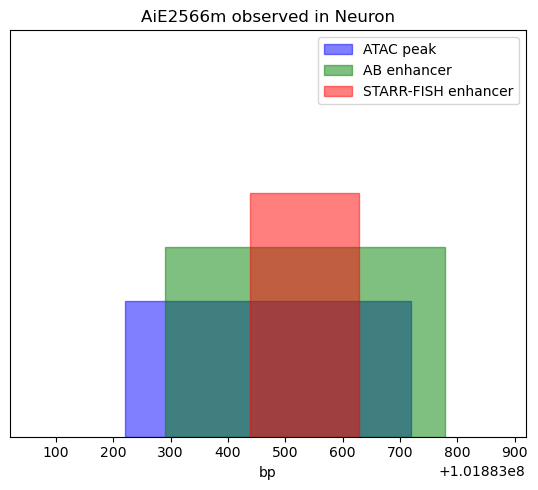

In [480]:
# plot the overlap between the AB enhancer, ATAC peak, and chosen STARR-FISH enhancer
# does not take into consideration the ATAC peak data from IGV (manually checked)
fig, ax = plt.subplots(figsize=(5.5,5))

ax.add_patch(patches.Rectangle((enhancer_peaks['start (ATAC)'][x], 0), enhancer_peaks['end (ATAC)'][x] - enhancer_peaks['start (ATAC)'][x], 0.5, color='blue', alpha=0.5, label='ATAC peak'))
ax.add_patch(patches.Rectangle((enhancer_peaks['start (enhancer)'][x], 0), enhancer_peaks['end (enhancer)'][x] - enhancer_peaks['start (enhancer)'][x], 0.7, color='green', alpha=0.5, label='AB enhancer'))
ax.add_patch(patches.Rectangle((start, 0), end - start, 0.9, color='red', alpha=0.5, label='STARR-FISH enhancer'))

if enhancer_peaks['ATAC peak size'][x] > enhancer_peaks['enhancer size'][x]:
    ax.set_xlim(enhancer_peaks['start (ATAC)'][x] - 200, enhancer_peaks['end (ATAC)'][x]+200)

else:
    ax.set_xlim(enhancer_peaks['start (enhancer)'][x] - 200, enhancer_peaks['end (enhancer)'][x]+200)

ax.set_ylim(0,1.5)
ax.set_title(enhancer_peaks['enhancer ID'][x] + ' observed in ' + enhancer_peaks['observed cell type'][x])
ax.set_xlabel('bp')
ax.set_yticks([]) 
ax.set_yticklabels([]) 

ax.legend()
plt.tight_layout()
# plt.savefig(rf'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_overlap_plots\{name}.png', dpi=300)
plt.show()

In [561]:
# append STARR-FISH enhancer data to a list
final_pos_ctrls.append(enhancer)
final_pos_ctrls

In [613]:
final_pos_ctrls

[['AiE0680m_1', 'chr12', 63319677, 63319867],
 ['AiE2586m_1', 'chr9', 57566008, 57566198],
 ['AiE2356m_1', 'chr9', 56037526, 56037716],
 ['AiE2356m_2', 'chr9', 56037108, 56037298],
 ['AiE0784m_1', 'chr10', 75411507, 75411697],
 ['AiE0779m_6xC2_1', 'chr10', 19829367, 19829557],
 ['AiE0743m_3xC2_1', 'chr3', 135176767, 135176957],
 ['AiE0050m_3xC2_1', 'chr16', 88302565, 88302755],
 ['AiE2016m_1', 'chr1', 193298474, 193298664],
 ['AiE2016m_2', 'chr1', 193298203, 193298393],
 ['AiE2135m_1', 'chr4', 119044349, 119044539],
 ['AiE2135m_2', 'chr4', 119044878, 119045068],
 ['AiE2004m_1', 'chr15', 60705994, 60706184],
 ['AiE0086m_1', 'chr16', 50174466, 50174656],
 ['AiE2402m_1', 'chr16', 24097309, 24097499],
 ['AiE0486m_1', 'chr9', 54172659, 54172849],
 ['AiE2182m_3xC2_1', 'chr4', 4249433, 4249623],
 ['AiE0780m_1', 'chr2', 129734155, 129734345],
 ['AiE0724m_1', 'chr6', 23107186, 23107376],
 ['AiE0873m_3xC2_1', 'chr17', 54223679, 54223869],
 ['AiE0390m_3xC2_1', 'chr13', 15543925, 15544115],
 ['AiE

In [563]:
len(final_pos_ctrls)

41

In [580]:
# manually find coordinates for extra positive controls from AB hall of fame & IGV browser w/ snATAC data
coords = 'chr7:123,861,817-123,862,006'
enhancer = ['AiE3114m_1', 'chr7', 123861817, 123862006]
enhancer

['AiE3114m_1', 'chr7', 123861817, 123862006]

In [564]:
# create final dataframe of STARR-FISH positive control enhancer coordinates
final_df = pd.DataFrame(final_pos_ctrls, columns=['enhancer ID', 'chr', 'start', 'end'])

In [567]:
final_df = final_df.drop(27)

In [573]:
final_df['end'] = final_df['end'].astype(int)

In [575]:
final_df = final_df.reindex(columns=['chr', 'start', 'end', 'enhancer ID'])

In [581]:
final_df

,chr,start,end,enhancer ID
0,chr12,63319677,63319867,AiE0680m_1
1,chr9,57566008,57566198,AiE2586m_1
2,chr9,56037526,56037716,AiE2356m_1
3,chr9,56037108,56037298,AiE2356m_2
4,chr10,75411507,75411697,AiE0784m_1
5,chr10,19829367,19829557,AiE0779m_6xC2_1
6,chr3,135176767,135176957,AiE0743m_3xC2_1
7,chr16,88302565,88302755,AiE0050m_3xC2_1
8,chr1,193298474,193298664,AiE2016m_1
9,chr1,193298203,193298393,AiE2016m_2


In [600]:
final_df['end'] - final_df['start']

0     190
1     190
2     190
3     190
4     190
5     190
6     190
7     190
8     190
9     190
10    190
11    190
12    190
13    190
14    190
15    190
16    190
17    190
18    190
19    190
20    190
21    190
22    190
23    190
24    190
25    190
26    190
28    190
29    190
30    190
31    190
32    190
33    190
34    190
35    190
36    190
37    190
38    190
39    190
40    190
dtype: int64

In [598]:
final_df.iloc[32:, 2] = final_df.iloc[32:, 2] + 1

In [608]:
final_df['chr'].dtype

dtype('O')

In [609]:
final_df.to_csv(r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.bed', sep='\t', header=None, index=None)

##### *Plot all overlaps between AB enhancers and ATAC peak regions*

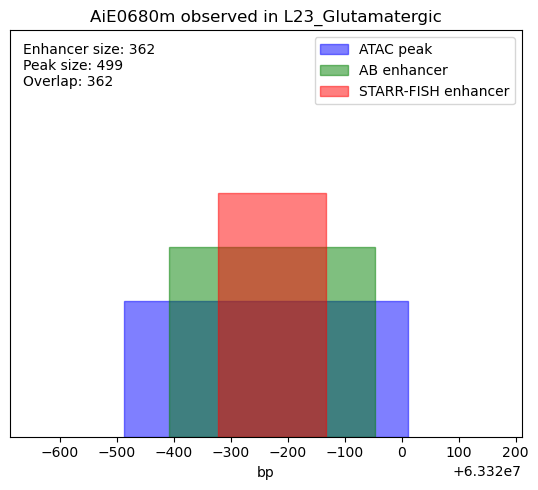

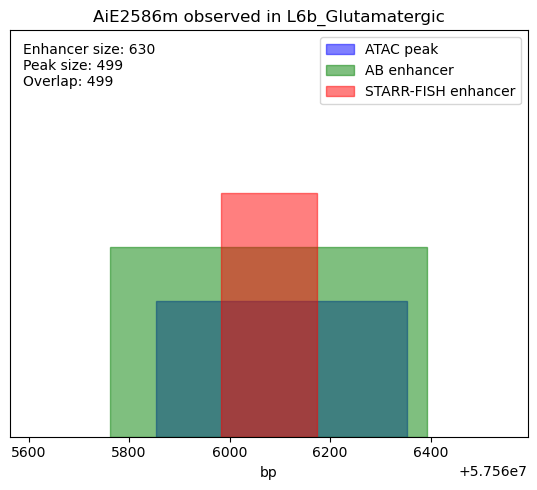

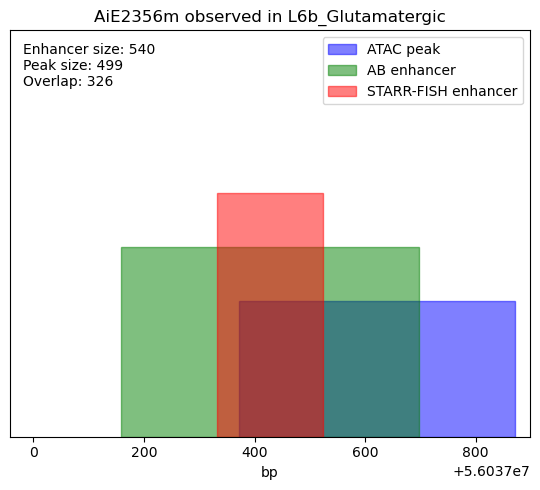

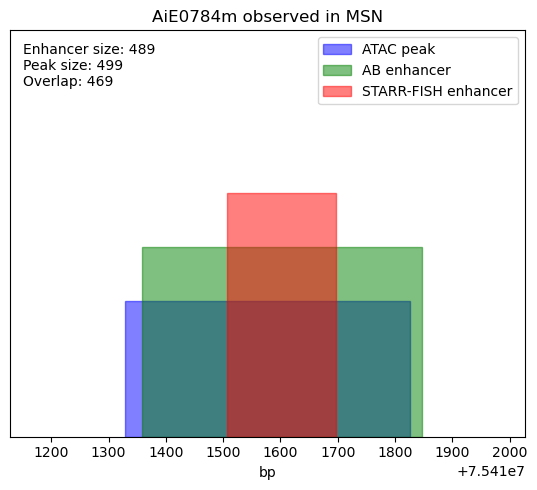

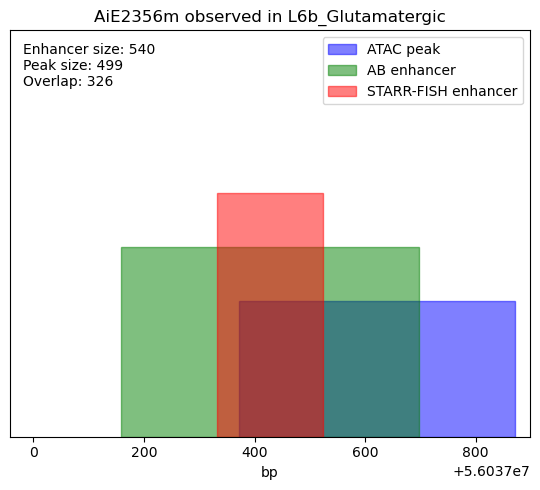

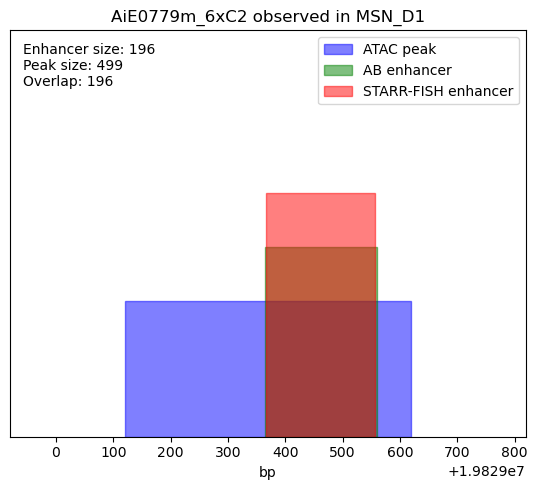

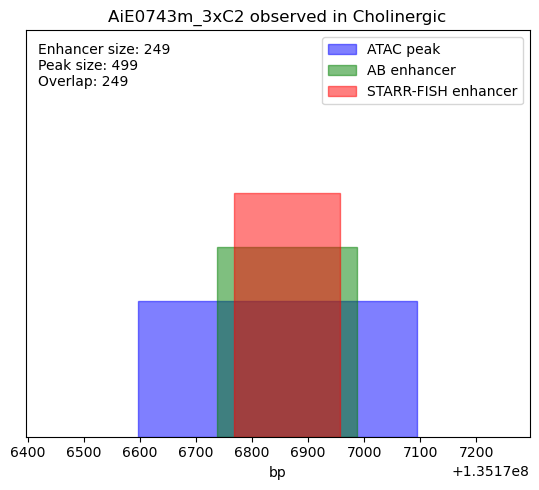

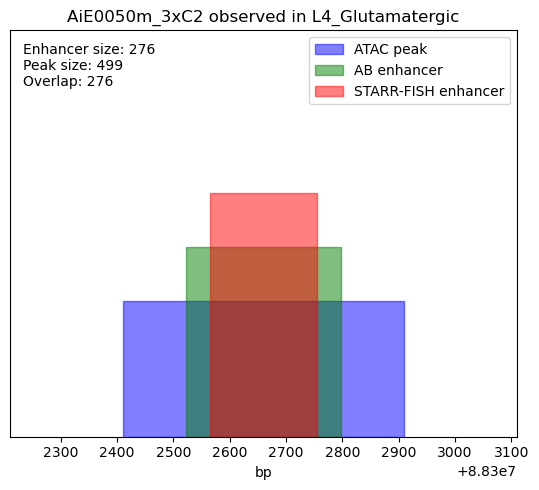

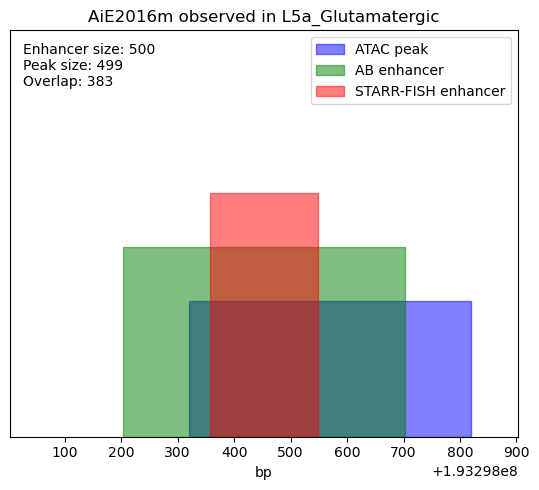

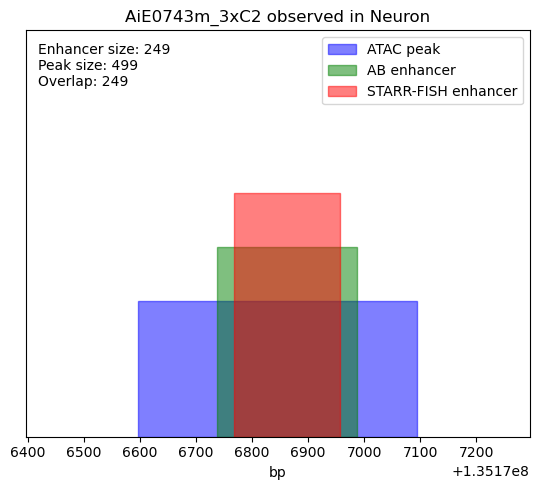

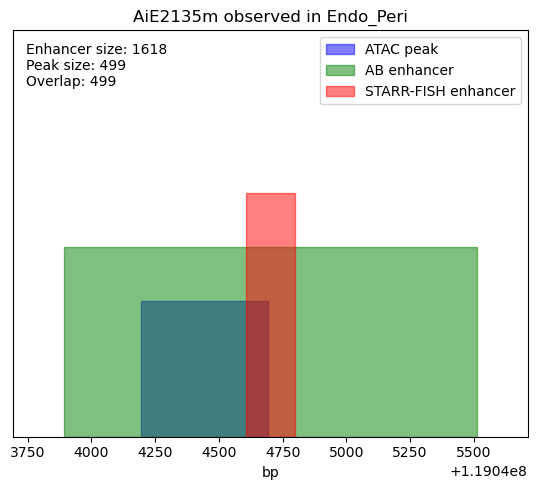

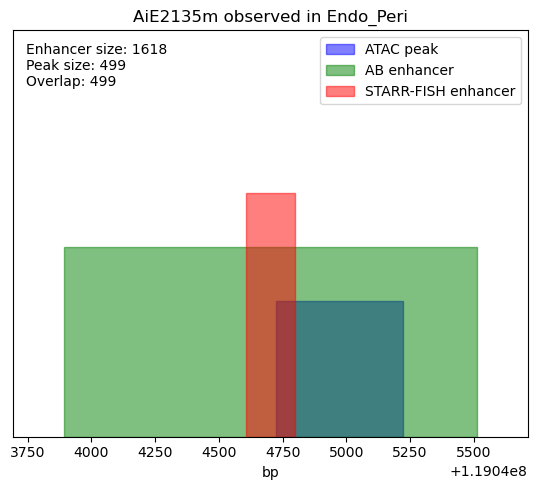

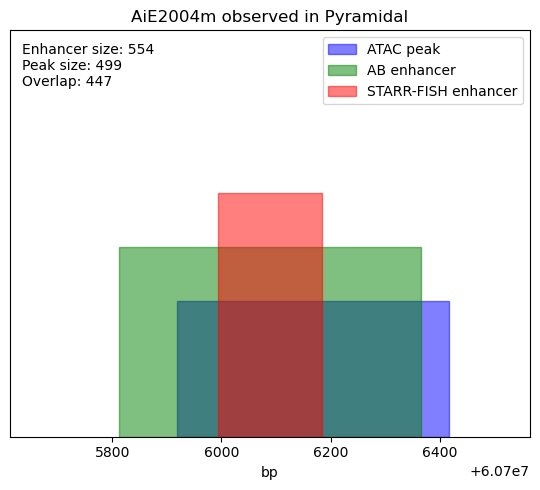

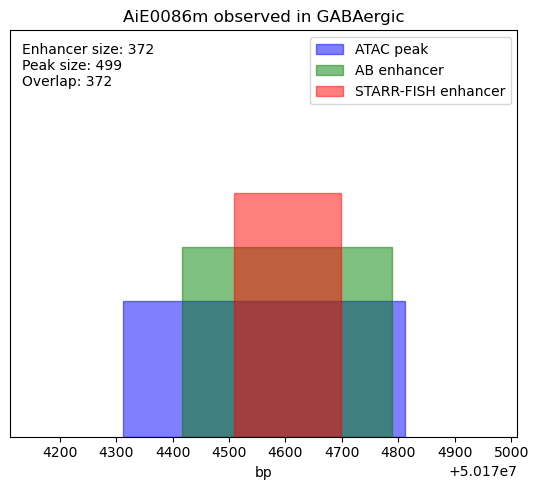

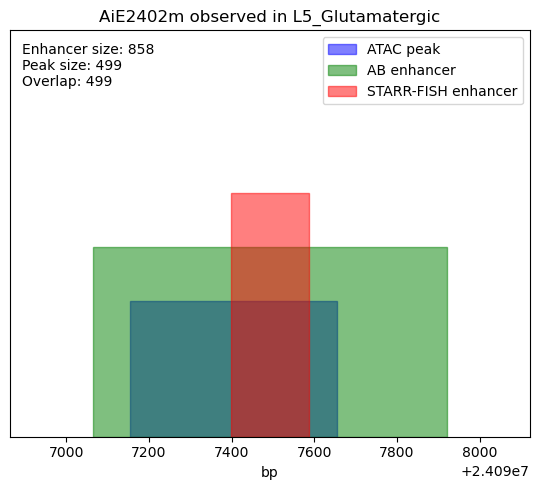

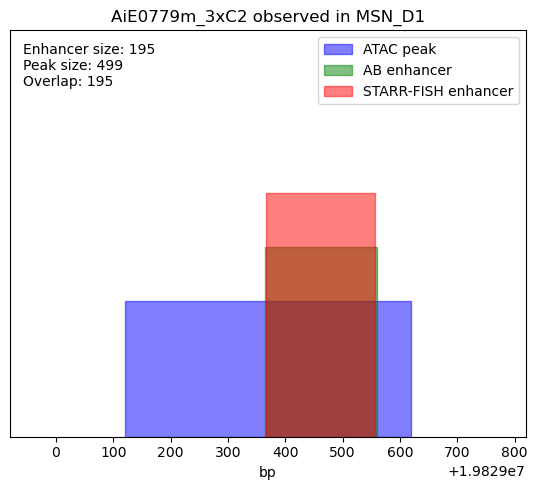

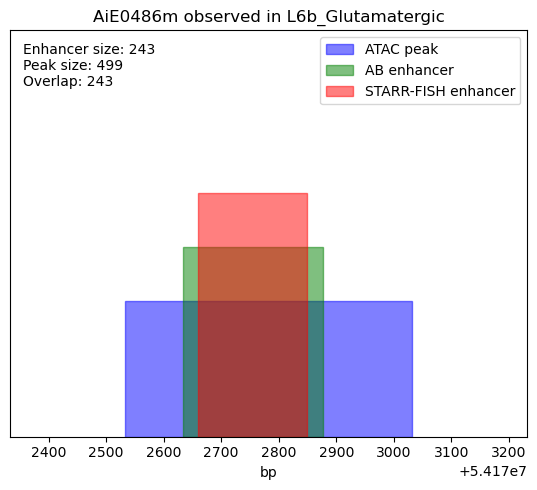

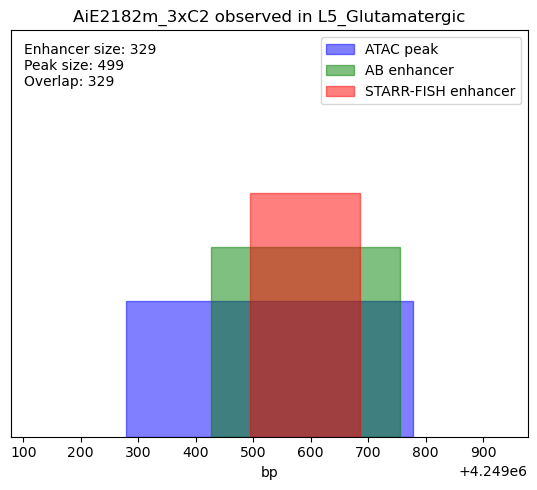

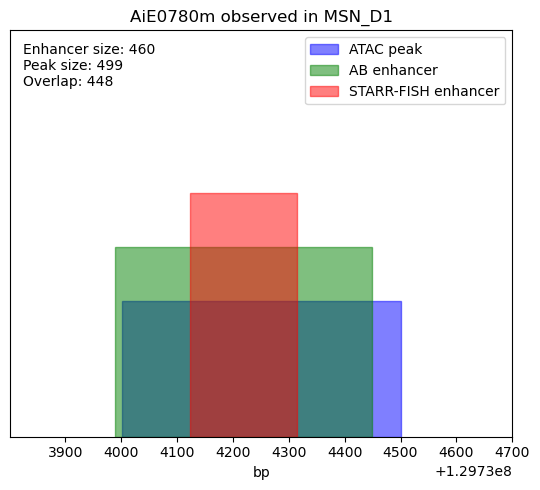

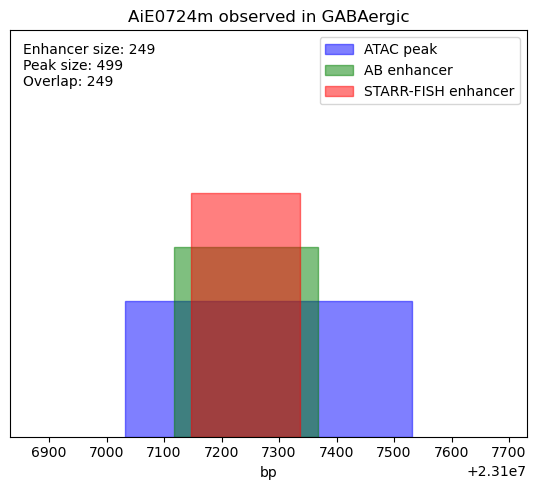

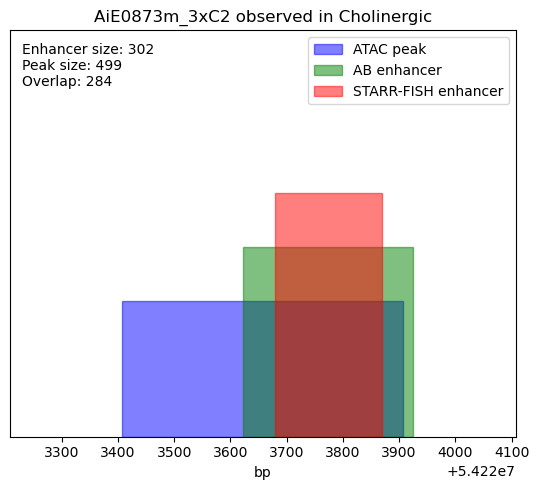

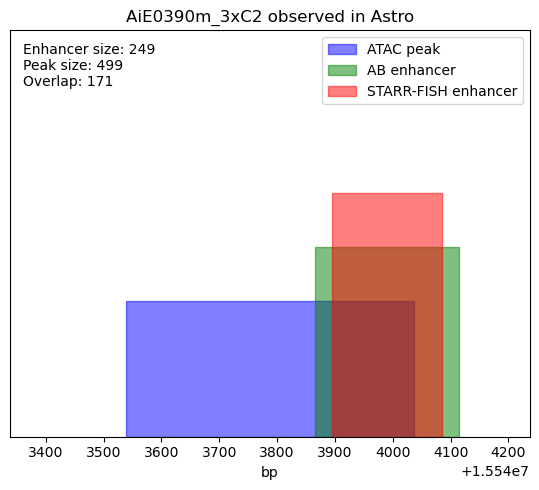

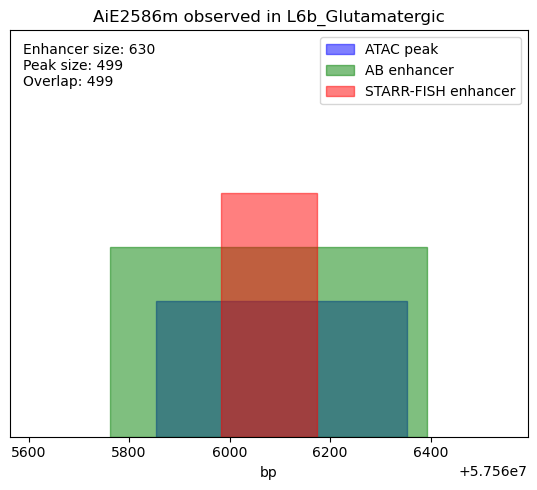

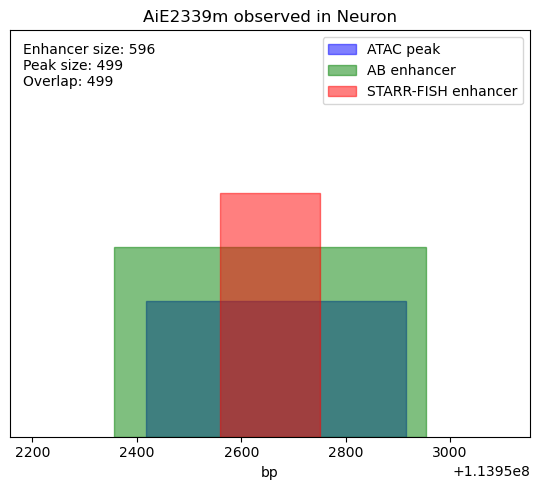

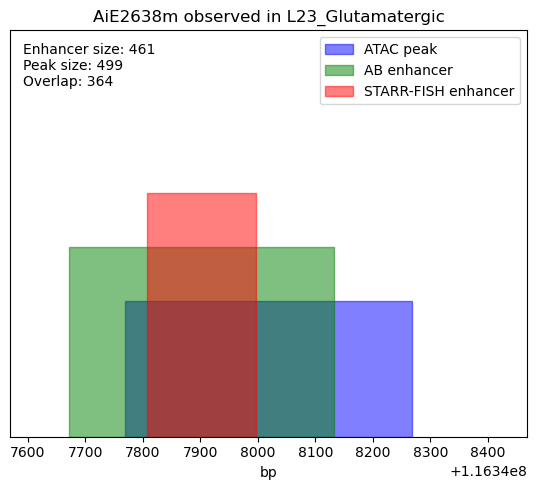

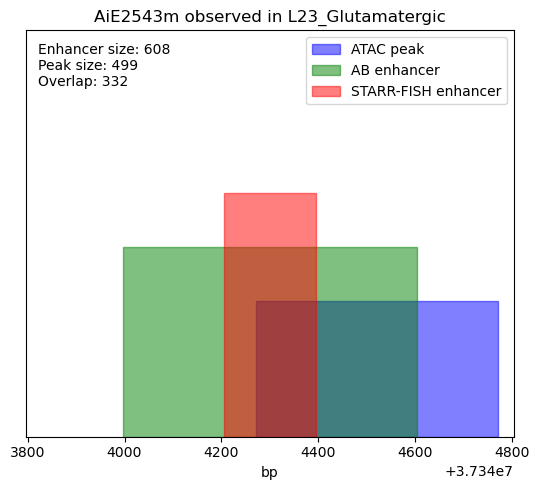

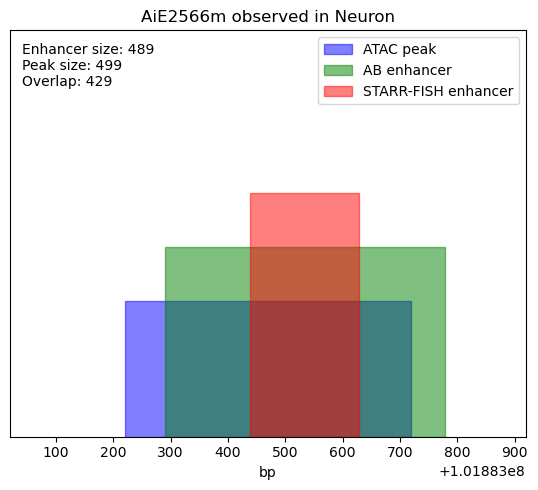

In [237]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText

for i in range(len(enhancer_peaks)):
    
    fig, ax = plt.subplots(figsize=(5.5,5))

    # add coordinates for STARR-FISH enhancer
    start = (enhancer_peaks['start (enhancer)'][i] + ((enhancer_peaks['enhancer size'][i] - 190) / 2)).astype(int)
    end = (start + 190).astype(int)
    
    ax.add_patch(patches.Rectangle((enhancer_peaks['start (ATAC)'][i], 0), enhancer_peaks['end (ATAC)'][i] - enhancer_peaks['start (ATAC)'][i], 0.5, color='blue', alpha=0.5, label='ATAC peak'))
    ax.add_patch(patches.Rectangle((enhancer_peaks['start (enhancer)'][i], 0), enhancer_peaks['end (enhancer)'][i] - enhancer_peaks['start (enhancer)'][i], 0.7, color='green', alpha=0.5, label='AB enhancer'))
    ax.add_patch(patches.Rectangle((start, 0), end - start, 0.9, color='red', alpha=0.5, label='STARR-FISH enhancer'))

    if enhancer_peaks['ATAC peak size'][i] > enhancer_peaks['enhancer size'][i]:
        ax.set_xlim(enhancer_peaks['start (ATAC)'][i] - 200, enhancer_peaks['end (ATAC)'][i]+200)

    else:
        ax.set_xlim(enhancer_peaks['start (enhancer)'][i] - 200, enhancer_peaks['end (enhancer)'][i]+200)
    
    ax.set_ylim(0,1.5)
    ax.set_title(enhancer_peaks['enhancer ID'][i] + ' observed in ' + enhancer_peaks['observed cell type'][i])
    ax.set_xlabel('bp')
    ax.set_yticks([]) 
    ax.set_yticklabels([])  
    
    name = enhancer_peaks['enhancer ID'][i]
    overlap = enhancer_peaks['overlap'][i]
    enhsize = enhancer_peaks['enhancer size'][i]
    peaksize = enhancer_peaks['ATAC peak size'][i]
    anchored_text = AnchoredText(f'Enhancer size: {enhsize}\nPeak size: {peaksize}\nOverlap: {overlap}', loc=2, frameon=False)
    ax.add_artist(anchored_text)
    
    ax.legend()
    plt.tight_layout()
    # plt.savefig(rf'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\overlap_plots\{name}.png', dpi=300)
    plt.show()

In [175]:
?ax.add_patch

Object `ax.add_patch` not found.


##### *Extract sequences for final positive control STARR-FISH enhancers*

In [610]:
# define windows and wsl paths to appropriate bed files
bedtools = '/home/zgibbs/miniconda3/envs/utility/bin/bedtools'
pos_ctrls = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.bed'
pos_ctrls_wsl = wsl_path(pos_ctrls)
mm10 = r'C:\Users\zgibbs\mm10.fa'
mm10_wsl = wsl_path(mm10)
results = r'C:\Users\zgibbs\Allen_Brain_hall_of_fame_controls\final_pos_ctrls.fa'
results_wsl = wsl_path(results)

In [611]:
# define the actual bedtools command to execute
command = f'{bedtools} getfasta -fi {mm10_wsl} -bed {pos_ctrls_wsl} -fo {results_wsl}'

In [612]:
# define command to run using the bash file generated from the above function
run_command = run_wsl_command(command)
!{run_command}